# 01 — Auditoria da vantagem reivindicada

**Pergunta:** a superioridade do DQN sobre o baseline decorre do aprendizado, ou
da configuração do adversário?

O manuscrito auditado reporta 82,9 % de conforto contra 50,9 % de um termostato —
uma vantagem de aproximadamente +32 pontos percentuais. Este notebook decompõe
esse número, atribuindo cada incremento à sua causa.

Todos os controladores operam sob **condições idênticas**: mesma física, mesma
matriz de cenários, mesmo horizonte de decisão (*action repeat* 2) e mesmo espaço
de ação discreto. Sem essa equalização, a comparação mediria o protocolo, e não a
política.

In [1]:
%matplotlib inline
import sys, warnings
sys.path.insert(0, '/home/renan/Downloads/air_conditioning_classroom/v5')
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from hvac import results as R
from hvac import figures as F

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)
F.aplicar_estilo()

## 1.1 Comparação sob condições idênticas

O controlador PI foi sintonizado por busca em grade sobre a matriz de cenários
(K_p = 1,3; K_i = 0,2). Os agentes DQN vêm de 550 000 passos de treinamento.

In [2]:
comp = R.comparacao_controladores()
comp.round(2)

,controlador,comfort_wide_pct,comfort_narrow_pct,abs_dev_from_ideal,overheat_pct,energy_kwh_day,cost_brl_day,changes_per_hour
0,PI sintonizado,86.50,83.83,0.71,5.17,10.40,9.24,1.05
1,DQN Agressivo (550k),86.50,83.83,0.77,5.17,11.66,10.44,1.22
2,DQN Equilibrado (550k),86.50,83.83,0.89,5.17,10.90,9.72,0.78
3,DQN Passivo (550k),86.50,83.67,0.87,5.17,10.79,9.59,0.79
4,Termostato zona morta = 1 °C,77.67,20.50,1.78,14.00,8.12,7.39,0.20
5,Termostato zona morta = 0,54.00,12.17,2.10,37.67,7.55,6.88,0.97


### Leitura

O PI **domina os três perfis DQN simultaneamente em qualidade e em custo**: mesmo
conforto na faixa larga (86,5 %), mesmo conforto na faixa estreita (83,8 %), menor
desvio absoluto do ideal e menor consumo. Duas constantes sintonizadas igualam ou
superam 550 000 passos de treinamento.

Repare também que os **três perfis empatam** no conforto binário. A métrica que o
manuscrito usa como principal está saturada: ela não separa perfis que diferem em
gradiente de conforto, penalidade de energia e penalidade de troca. É por isso
que a faixa estreita e o desvio absoluto são reportados ao lado — são as métricas
em que os perfis de fato se distinguem.

## 1.2 Decomposição da vantagem

Cada linha acrescenta **um único fator** ao anterior, de modo que o incremento é
atribuível.

In [3]:
dec = R.decomposicao_da_vantagem()
dec.round(2)

,etapa,conforto_larga_pct,atribuivel_a,ganho_pp
0,Termostato (zona morta = 0),54.00,baseline do manuscrito,54.00
1,+ histerese (zona morta = 1 °C),77.67,configuração do baseline,23.67
2,"PI sintonizado (Kp=1,3; Ki=0,2)",86.50,controle clássico,8.83
3,DQN (550k passos),86.50,aprendizado,0.00


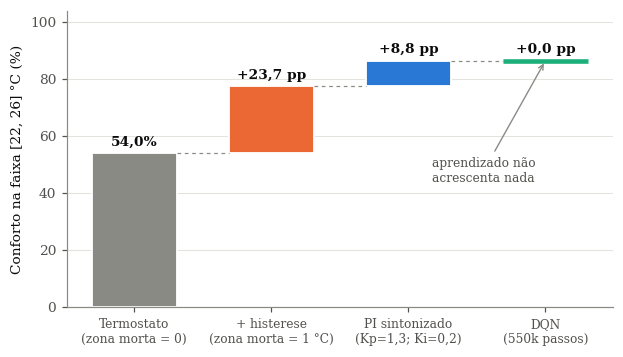

In [4]:
fig = F.fig_decomposicao(dec)
plt.close(fig)   # evita a exibição dupla do backend inline
fig

### Leitura — o achado central

| Etapa | Ganho | Atribuível a |
|---|---|---|
| Termostato do manuscrito | — | ponto de partida |
| Adicionar apenas histerese | **+23,7 pp** | configuração do baseline |
| PI sintonizado | **+8,8 pp** | controle clássico |
| DQN, 550k passos | **+0,0 pp** | **aprendizado** |

Praticamente **toda** a vantagem reivindicada é atribuível à configuração
inadequada do adversário. Um termostato com zona morta nula comuta ao menor
desvio e estaciona no teto da faixa; acrescentar histerese — uma linha de código,
prática padrão em qualquer termostato comercial — já recupera 23,7 dos 32 pontos.

A afirmação "82,9 % contra 50,9 %" é tecnicamente verdadeira e substantivamente
enganosa: compara-se contra um adversário artificialmente incapaz.

> **Ressalva metodológica, não eliminada.** O PI foi sintonizado sobre a mesma
> matriz usada para avaliar. O resultado deve ser lido como *"o PI iguala o DQN
> nas condições em que ambos foram ajustados"*, e não como superioridade geral.
> Refazer a sintonia apenas numa partição de calibração é trabalho pendente.

## 1.3 Por que isso não é acidente

O ambiente é uma planta **monovariável de primeira ordem**, essencialmente linear
na faixa de operação, com **modelo conhecido** de dois parâmetros, perturbação
mensurável e objetivo de rastrear um setpoint. Esse é o caso canônico em que
controle proporcional-integral é ótimo ou quase-ótimo.

O aprendizado por reforço tem vantagem estabelecida em regimes que esta
formulação não exibe: não-linearidade forte, acoplamento de alta dimensão,
objetivos não expressáveis como custo quadrático, decisões combinatórias de
alocação, ou modelo desconhecido. O notebook 03 documenta três tentativas de
construir tais regimes.